# Tugas 3 - IDA* Algorithm

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# IDA* Algorithm
"""
Start : Saint Lous
Goal  : Saul St Marie

Rumus Penting :
- fn(n) <= Threshold
- f(n) = g(n) + h(n)
g(n) : Actual Cost/Path Cost
h(n) : Heuristic Cost
f(n) : Total Estimated Cost
"""

# Data Kota
data_kota = {
    'VAN': {'name': 'Vancouver', 'hcost': 432, 'neighbors': {'CGY': 100, 'SEA': 45}},
    'CGY': {'name': 'Calgary', 'hcost': 334, 'neighbors': {'VAN': 100, 'SEA': 118, 'HLN': 130, 'WPG': 180}},
    'WPG': {'name': 'Winnipeg', 'hcost': 156, 'neighbors': {'CGY': 180, 'HLN': 137, 'DLH': 103, 'SSM': 156}},
    'SSM': {'name': 'Sault Ste Marie', 'hcost': 0, 'neighbors': {'WPG': 156, 'DLH': 110, 'TOR': 90, 'YUL': 193}},
    'YUL': {'name': 'Montreal', 'hcost': 193, 'neighbors': {'SSM': 193, 'TOR': 115, 'BOS': 69, 'NYC': 99}},
    'BOS': {'name': 'Boston', 'hcost': 240, 'neighbors': {'YUL': 69, 'NYC': 74}},
    'NYC': {'name': 'New York', 'hcost': 195, 'neighbors': {'BOS': 74, 'YUL': 99, 'PIT': 69, 'DCA': 76}},
    'TOR': {'name': 'Toronto', 'hcost': 90, 'neighbors': {'SSM': 90, 'YUL': 115, 'PIT': 80}},
    'PIT': {'name': 'Pittsburgh', 'hcost': 152, 'neighbors': {'NYC': 69, 'TOR': 80, 'DCA': 85, 'CHI': 81}},
    'DCA': {'name': 'Washington', 'hcost': 238, 'neighbors': {'NYC': 76, 'PIT': 85, 'RDU': 47}},
    'RDU': {'name': 'Raleigh', 'hcost': 251, 'neighbors': {'DCA': 47, 'CHS': 95, 'ATL': 96}},
    'CHS': {'name': 'Charleston', 'hcost': 322, 'neighbors': {'RDU': 95, 'ATL': 63, 'MIA': 116}},
    'MIA': {'name': 'Miami', 'hcost': 389, 'neighbors': {'CHS': 116, 'ATL': 120, 'MSY': 151}},
    'ATL': {'name': 'Atlanta', 'hcost': 272, 'neighbors': {'RDU': 96, 'CHS': 63, 'MIA': 120, 'BNA': 67, 'MSY': 100}},
    'BNA': {'name': 'Nashville', 'hcost': 221, 'neighbors': {'ATL': 67, 'STL': 85, 'LIT': 94}},
    'MSY': {'name': 'New Orleans', 'hcost': 322, 'neighbors': {'ATL': 100, 'MIA': 151, 'HOU': 80}},
    'HOU': {'name': 'Houston', 'hcost': 332, 'neighbors': {'MSY': 80, 'DAL': 45}},
    'DAL': {'name': 'Dallas', 'hcost': 303, 'neighbors': {'HOU': 45, 'LIT': 74, 'OKC': 46, 'ELP': 140}},
    'OKC': {'name': 'Oklahoma City', 'hcost': 237, 'neighbors': {'DAL': 46, 'LIT': 72, 'KCY': 61, 'SAF': 121}},
    'LIT': {'name': 'Little Rock', 'hcost': 240, 'neighbors': {'BNA': 94, 'DAL': 74, 'OKC': 72, 'STL': 60}},
    'STL': {'name': 'Saint Louis', 'hcost': 180, 'neighbors': {'BNA': 85, 'LIT': 60, 'KCY': 68, 'CHI': 104}},
    'CHI': {'name': 'Chicago', 'hcost': 107, 'neighbors': {'STL': 104, 'PIT': 81, 'DLH': 157, 'OMA': 142}},
    'KCY': {'name': 'Kansas City', 'hcost': 176, 'neighbors': {'OKC': 61, 'STL': 68, 'OMA': 68, 'DEN': 135}},
    'OMA': {'name': 'Omaha', 'hcost': 150, 'neighbors': {'CHI': 142, 'KCY': 68, 'DLH': 74, 'DEN': 130}},
    'DLH': {'name': 'Duluth', 'hcost': 110, 'neighbors': {'WPG': 103, 'SSM': 110, 'CHI': 157, 'OMA': 74, 'HLN': 150}},
    'HLN': {'name': 'Helena', 'hcost': 254, 'neighbors': {'CGY': 130, 'WPG': 137, 'DLH': 150, 'DEN': 174, 'SLC': 126, 'SEA': 189}},
    'SEA': {'name': 'Seattle', 'hcost': 434, 'neighbors': {'VAN': 45, 'CGY': 118, 'HLN': 189, 'PDX': 44}},
    'PDX': {'name': 'Portland', 'hcost': 452, 'neighbors': {'SEA': 44, 'SLC': 175, 'SFO': 151}},
    'SFO': {'name': 'San Francisco', 'hcost': 499, 'neighbors': {'PDX': 151, 'SLC': 156, 'LAX': 100}},
    'SLC': {'name': 'Salt Lake City', 'hcost': 344, 'neighbors': {'PDX': 175, 'SFO': 156, 'HLN': 126, 'DEN': 101, 'LAS': 89}},
    'DEN': {'name': 'Denver', 'hcost': 270, 'neighbors': {'HLN': 174, 'SLC': 101, 'OMA': 130, 'KCY': 135, 'SAF': 70}},
    'SAF': {'name': 'Santa Fe', 'hcost': 318, 'neighbors': {'DEN': 70, 'OKC': 121, 'PHX': 85, 'ELP': 65}},
    'ELP': {'name': 'El Paso', 'hcost': 370, 'neighbors': {'SAF': 65, 'DAL': 140, 'PHX': 191}},
    'PHX': {'name': 'Phoenix', 'hcost': 396, 'neighbors': {'SAF': 85, 'ELP': 191, 'LAS': 66, 'LAX': 109}},
    'LAS': {'name': 'Las Vegas', 'hcost': 418, 'neighbors': {'SLC': 89, 'PHX': 66, 'LAX': 88}},
    'LAX': {'name': 'Los Angeles', 'hcost': 484, 'neighbors': {'SFO': 100, 'LAS': 88, 'PHX': 109}}
}

# Algoritma

def ida_star(graph, start, goal):

    threshold = graph[start]["hcost"] # set threshold (180)

    while True: # loop iteratif
        result = visit(graph, start, goal, 0, threshold, [start])

        if isinstance(result, tuple):  # solusi ditemukan
            return result

        if result == float("inf"): # jika tidak ada node lagi, berarti path tidak ditemukan
            return None

        threshold = result


def visit(graph, node, goal, g, threshold, path):
    h = graph[node]["hcost"] # hcost
    f = g + h # total cost dari actual cost+hcost (0+180)
    if f > threshold: # hanya boleh menjelajahi node dengan f < threshold (180)
        return f

    if node == goal:
        return (path, g)

    minimum = float("inf") # (306) (300) (244) (211)

    for neighbor, cost in graph[node]["neighbors"].items(): # loop setiap neighbor dan cost

        if neighbor in path: # mencegah mengulang path yang sama
            continue

        result = visit( # recursive call, memanggil func lagi tapi dengan argumen yang berbeda
            graph,
            neighbor, # neighbor dari STL
            goal,
            g + cost, # 0+85
            threshold,
            path + [neighbor]
        )

        if isinstance(result, tuple):
            return result

        minimum = min(minimum, result)

    return minimum


start = "STL"
goal = "SSM"

result = ida_star(data_kota, start, goal)

if result:
    path, cost = result
    print("Path:", " -> ".join(path))
    print("Total Cost:", cost)
else:
    print("Path tidak ditemukan")

Path: STL -> KCY -> OMA -> DLH -> SSM
Total Cost: 320


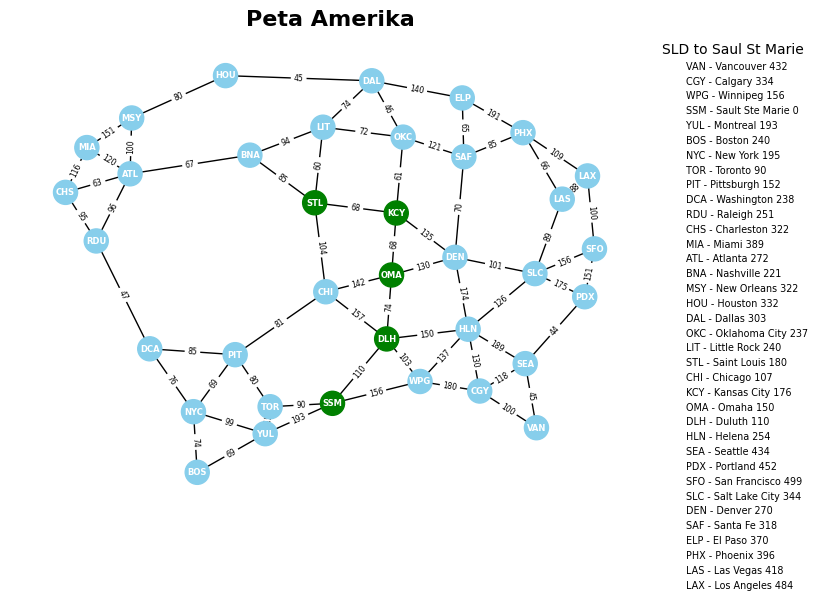

In [ ]:
# Visualisasi Graf
G = nx.Graph()
legend_elements=[]

for kota, detail in data_kota.items():
  # List Legenda
  label_legend = f"{kota} - {detail['name']} {detail['hcost']}"
  element = Line2D([0], [0], color='w',marker=False, label=label_legend,
                     markerfacecolor='skyblue', markersize=5)
  legend_elements.append(element)
  for neighbor, cost in detail['neighbors'].items():
    # Path Cost
    G.add_edge(kota, neighbor, weight=cost)

# Color Map Path
color_map = []
for node in G.nodes():
    if node in path:
        color_map.append('green')  # Warna path
    else:
        color_map.append('skyblue') # Warna lain

pos = nx.spring_layout(G, seed=110)
nx.draw(G, pos,
        with_labels=True,
        font_size=6,
        font_color="white",
        font_weight="bold",
        node_color=color_map)
edge_labels = nx.get_edge_attributes(G, 'weight')

# Label Path Cost
nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=5.5)
#Legenda
plt.legend(handles=legend_elements,
           bbox_to_anchor=(1, 1),
           fontsize='x-small',
           frameon = False,
           title="SLD to Saul St Marie")
# Judul
plt.title('Peta Amerika', fontsize=16, fontweight='bold')

plt.show()